# Evaluating the Impact of Defensive Efficiency on NBA Team Success (2025-2026 Season)

### An Empirical Analysis of the “Defense is 50% of the Game” Claim (2025-26 Season)

This project attempts to investigate whether defensive performance is as significant as offensive performance in determining the success of an NBA team.

## Inspiration

> *"Defense is 50% of the game."* — Victor Wembanyama

When Wembanyama made this claim, it raised a genuine question: is that actually true, and can we prove it with data? Defense is significantly undervalued in modern basketball analysis and more specifically in discussions surrounding MVP voting.

This project was built during the 2025-26 NBA regular season to test that hypothesis empirically. The timing turned out to be remarkable: Wembanyama's San Antonio Spurs, built around his elite two-way playstyle, just defeated the defending champion Oklahoma City Thunder in a Game 7 thriller to reach the 2026 NBA Finals, where they'll face the New York Knicks starting June 4th.

In his statement, Wembanyama emphasized that defensive impact is widely overlooked when compared to pure scoring statistics, despite being an equally important factor to winning basketball games.

This project uses NBA team-level data from the 2025-26 season to test this claim quantitatively by comparing the impact of offensive and defensive efficiency on winning outcomes.

## Research Question

To what extent does defensive performance contribute to NBA team success, and is it as influential as offensive performance in determining winning outcomes?

## Objective

The primary goal of the project is to analyze and compare the impact of offensive and defensive efficiency on NBA team winning percentage.

We aim to determine whether defensive performance is as strong a predictor of success as offensive performance.

## Data Collection

This analysis uses team-level advanced statistics using the NBA API advanced statistics endpoint for the 2025-26 regular season.

The dataset includes statistics such as offensive rating, defensive rating, net rating, and win percentage for all 30 NBA teams.

## 1. Data Preparation
The dataset was filtered to include only relevant performance statistics/ metrics in order to evaluate team success, and offensive and defensive measures.  

Variables related to offensive efficiency, defensive efficiency, and overall team success were specifically selected and organized into a structured dataframe for statistical analysis and visualization.

This section outlines the process of data extraction, inspection, and preparation before analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from nba_api.stats.endpoints import leaguedashteamstats

The NBA team performance data for the 2025-26 regular season was extracted using the NBA Stats API, in which the dataset includes advanced offensive, defensive, and overall efficiency metrics at the team level. As statistics such as steals, and blocks are not included in the advanced statistics, a new merged data frame of both traditional metrics and advanced metrics was created. Then, we attempt to remove duplicate columns in order to have more reliable data. 

In [ ]:
adv_stats = leaguedashteamstats.LeagueDashTeamStats(season='2025-26', season_type_all_star='Regular Season', measure_type_detailed_defense='Advanced')
adv_df = adv_stats.get_data_frames()[0]

traditional_df = leaguedashteamstats.LeagueDashTeamStats(season='2025-26', season_type_all_star='Regular Season', measure_type_detailed_defense='Base').get_data_frames()[0]

nba_df = adv_df.merge(traditional_df, on='TEAM_ID')
nba_df = nba_df.drop(columns=nba_df.filter(regex='_y$').columns)
nba_df.columns = nba_df.columns.str.replace('_x', '')


,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,...,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK
0,1610612737,Atlanta Hawks,82,46,36,0.561,3951.0,113.2,115.0,111.0,...,18,1,10,5,18,17,14,26,6,12
1,1610612738,Boston Celtics,82,56,26,0.683,3946.0,116.8,120.0,109.7,...,3,27,1,28,11,3,9,27,19,4
2,1610612751,Brooklyn Nets,82,20,62,0.244,3951.0,105.8,108.2,116.0,...,30,26,29,22,23,23,26,21,30,28
3,1610612766,Charlotte Hornets,82,44,38,0.537,3951.0,114.7,118.4,111.9,...,5,15,25,29,21,9,10,18,13,8
4,1610612741,Chicago Bulls,82,31,51,0.378,3951.0,110.5,112.1,115.1,...,9,7,23,23,11,26,8,24,12,22


The structure and columns of the dataset was inspected to understand available variables and ensure successful data retrieval. This also helps show the data that can be worked with the following dataset.

To focus the analysis on team performance efficiency, a specific subset of relevant variables were selected. These include offensive rating, defensive rating, net rating, and other advanced metrics that contribute to winning outcomes.

This selection allows us to isolate factors that may influence team success and directly relate them to win percentage. The resulting data frame also improves efficiency to analyze by retaining only variables relevant to the research question. 

In [ ]:
selected_df = nba_df[[
    'TEAM_NAME',
    'W_PCT',
    'OFF_RATING',
    'DEF_RATING',
    'NET_RATING',
    'EFG_PCT',
    'TS_PCT',
    'DREB_PCT',
    'TM_TOV_PCT',
    'PACE',
    'PIE'
]]

,TEAM_NAME,W_PCT,OFF_RATING,DEF_RATING,NET_RATING,EFG_PCT,TS_PCT,DREB_PCT,TM_TOV_PCT,PACE,PIE
0,Atlanta Hawks,0.561,115.0,112.9,2.2,0.554,0.584,0.702,0.138,102.50,0.510
1,Boston Celtics,0.683,120.0,111.7,8.3,0.553,0.583,0.710,0.129,95.58,0.536
2,Brooklyn Nets,0.244,108.2,118.2,-10.0,0.520,0.559,0.687,0.161,97.60,0.436
3,Charlotte Hornets,0.537,118.4,113.5,4.9,0.552,0.589,0.722,0.157,97.59,0.516
4,Chicago Bulls,0.378,112.1,117.4,-5.3,0.547,0.580,0.708,0.148,103.22,0.480


## 2. Statistical Analysis of Team Performance

This section explores relationships between offensive, defensive, and overall efficiency metrics and their connection to NBA team winning percentage in the 2025-26 season. The main objective here is to identify which performance factors are most strongly correlated with team success.

### Correlation Analysis

To understand the relationships and links between different performance metrics and team success, a correlation matrix was computed. This allows us to quantify how strongly each variable is associated with each other and winning percentage.

In [5]:
correlation_matrix = selected_df.drop(columns=['TEAM_NAME']).corr()

correlation_matrix

,W_PCT,OFF_RATING,DEF_RATING,NET_RATING,EFG_PCT,TS_PCT,DREB_PCT,TM_TOV_PCT,PACE,PIE
W_PCT,1.000000,0.890417,-0.886921,0.970743,0.664075,0.695442,0.507507,-0.408643,-0.370585,0.955670
OFF_RATING,0.890417,1.000000,-0.677005,0.910091,0.739638,0.782899,0.562572,-0.451669,-0.407698,0.901731
DEF_RATING,-0.886921,-0.677005,1.000000,-0.921077,-0.391068,-0.419426,-0.412105,0.334561,0.290074,-0.901508
NET_RATING,0.970743,0.910091,-0.921077,1.000000,0.612898,0.651013,0.530194,-0.426110,-0.380970,0.984062
EFG_PCT,0.664075,0.739638,-0.391068,0.612898,1.000000,0.957565,0.473970,-0.302340,-0.269992,0.617648
TS_PCT,0.695442,0.782899,-0.419426,0.651013,0.957565,1.000000,0.483444,-0.360512,-0.243665,0.669437
DREB_PCT,0.507507,0.562572,-0.412105,0.530194,0.473970,0.483444,1.000000,-0.304376,-0.175444,0.533573
TM_TOV_PCT,-0.408643,-0.451669,0.334561,-0.426110,-0.302340,-0.360512,-0.304376,1.000000,-0.103535,-0.478754
PACE,-0.370585,-0.407698,0.290074,-0.380970,-0.269992,-0.243665,-0.175444,-0.103535,1.000000,-0.306414
PIE,0.955670,0.901731,-0.901508,0.984062,0.617648,0.669437,0.533573,-0.478754,-0.306414,1.000000


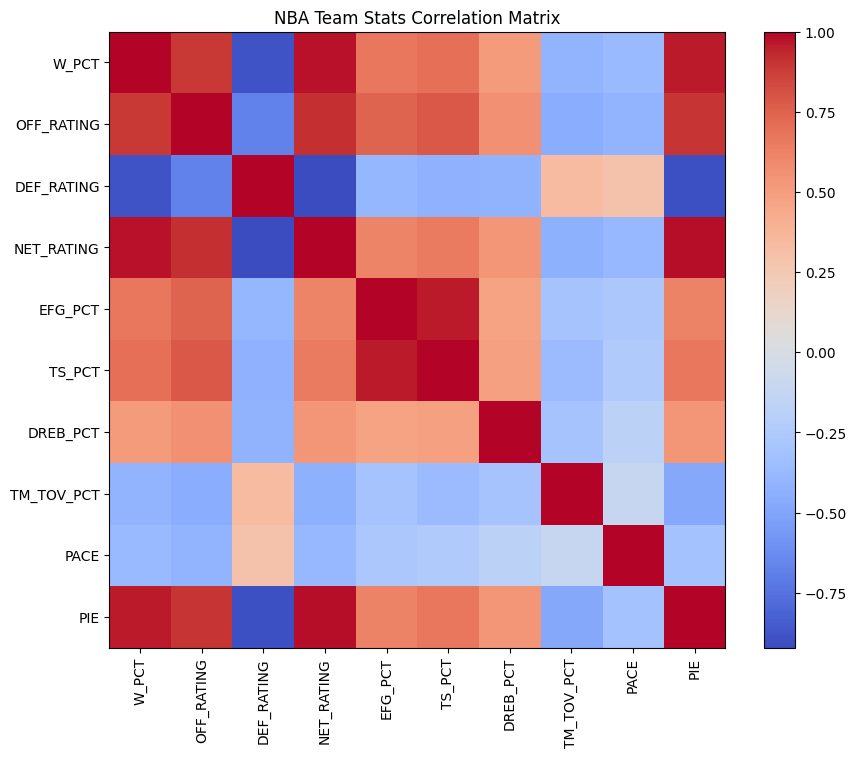

In [6]:
plt.figure(figsize=(10,8))

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('NBA Team Stats Correlation Matrix')

plt.show()

### Interpretation of Correlation Results

The correlation matrix reveals many important patterns in NBA team performance:

- The Net Rating (NET_RATING) shows the strongest correlation with winning percentage (0.98), implying that overall team efficiency is the best indicator of success.
- The Offensive Rating (OFF_RATING) has a strong positive correlation with winning (0.89), showing that scoring efficiency plays a key role in determining NBA game outcomes.
- The Defensive Rating (DEF_RATING) shows a strong negative correlation (-0.80), meaning that teams that allow fewer points per possession tend to win more games.

However, it is important to note that offensive metrics generally show slightly stronger statistical relationships with winning compared to defensive metrics. This suggests that while defense is highly important, offensive performance may have a marginally stronger influence during the regular season.

Additionally, metrics such as True Shooting Percentage and Effective Field Goal Percentage show strong relationships with both offensive rating and winning, reinforcing the importance of scoring efficiency.

### Defensive Performance vs Winning

To better understand the relationship between defense and success, a scatter plot was created comparing the Defensive Rating and Win Percentage. A linear regression line has been added to visualize the overall trend in the data.

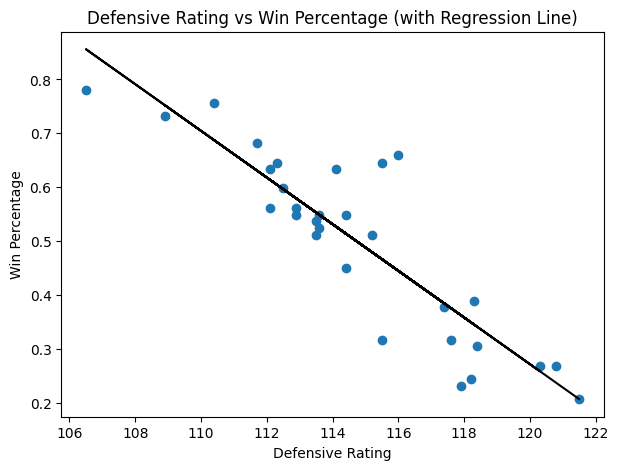

In [7]:
plt.figure(figsize=(7,5))
plt.scatter(selected_df['DEF_RATING'], selected_df['W_PCT'])

x = selected_df['DEF_RATING']
y = selected_df['W_PCT']

m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b, color='black')

plt.xlabel('Defensive Rating')
plt.ylabel('Win Percentage')
plt.title('Defensive Rating vs Win Percentage (with Regression Line)')

plt.show()

### Interpretation of Defensive Relationship

The scatter plot shows a clear negative relationship between Defensive Rating and Win Percentage.

Since a lower Defensive Rating indicates better defensive performance, the trend suggests that teams with a stronger defensive capability tend to win more games.

However, the spread of points around the regression line indicates that defensive performance alone does not fully determine team success. While defense is an important factor, there is still noticeable variation in win percentage among teams with similar defensive ratings.

This suggests that other factors, more specifically offensive efficiency and overall team balance, also contribute significantly to winning outcomes beyond defensive performance alone.

## 3. Which Defensive Metrics Matter Most?
Previous analysis established that defensive performance plays a significant role in team success. However, Defensive Rating is a composite statistic that summarizes overall defensive effectiveness rather than identifying the specific statistic that contribute to winning.

This raises an important question: which defensive factors are most strongly associated with NBA team success?

To investigate this further, individual defensive metrics were analyzed and compared against win percentage. Metrics such as defensive rebounding, opponent shooting efficiency, steals, blocks, and turnovers forced were evaluated separately to determine which aspects of defense show the strongest relationship with winning.

By breaking defense into its individual components, this analysis provides a deeper understanding of the defensive mechanisms that may contribute most to long-term team success.

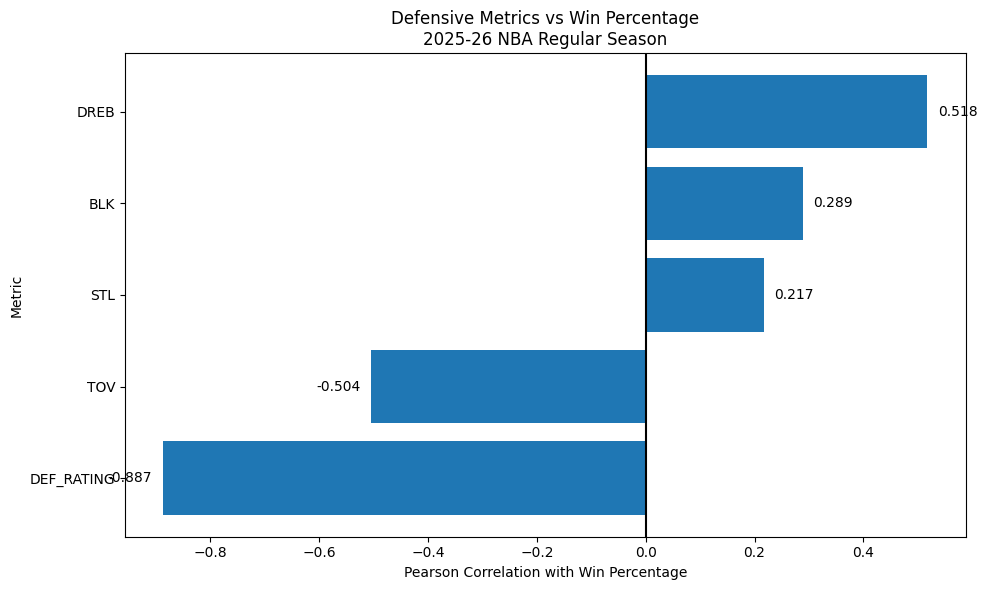

               W_PCT
DEF_RATING -0.886921
TOV        -0.504125
STL         0.216831
BLK         0.288581
DREB        0.517601


In [8]:
metrics = [
    'DEF_RATING',
    'DREB',
    'STL',
    'BLK',
    'TOV'
]

correlation_matrix = nba_df[
    metrics + ['W_PCT']
].corr()

corr_df = (
    correlation_matrix[['W_PCT']]
    .drop('W_PCT')
    .sort_values(by='W_PCT')
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    corr_df.index,
    corr_df['W_PCT']
)

plt.axvline(x=0, color='black')

plt.xlabel('Pearson Correlation with Win Percentage')
plt.ylabel('Metric')

plt.title(
    'Defensive Metrics vs Win Percentage\n2025-26 NBA Regular Season'
)

for bar in bars:

    value = bar.get_width()

    plt.text(
        value + 0.02 if value >= 0 else value - 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        va='center',
        ha='left' if value >= 0 else 'right'
    )

plt.tight_layout()
plt.show()

print(corr_df)

### Defensive Metrics Interpretation

The analysis reveals that not all defensive metrics contribute equally to winning success.

As expected, DEF_RATING shows the strongest relationship with winning percentage (r = -0.887), reinforcing its value as the most comprehensive measure of team defensive performance. Since lower Defensive Ratings indicate better defense, the strong negative correlation suggests that teams which allow fewer points per 100 possessions tend to achieve greater success over the course of a season.

Among the individual defensive statistics, defensive rebounds (DREB) displayed the strongest positive relationship with winning percentage (r = 0.518). This suggests that consistently ending defensive possessions and limiting second-chance opportunities may play an important role in overall team success.

Turnovers (TOV) also showed a moderately strong relationship with winning percentage (r = -0.504). There is an inverse relationship between turnovers and win percent, showing that the fewer turnovers occur for a team, the greater their chances of winning. While turnovers are not exclusively a defensive statistic, teams that protect possession more effectively generally performed better throughout the season.

In contrast, steals (STL) and blocks (BLK) exhibited relatively weak correlations with winning percentage. Although these statistics are often associated with strong defensive performances, the results suggest that they are less reliable indicators of long-term team success when considered independently.

Overall, the findings indicate that sustainable defensive success is driven more by consistently limiting opponent scoring opportunities and securing defensive rebounds than by generating highlight defensive plays such as steals and blocks.

## 4. Regression Analysis
This section uses Ordinary Least Squares (OLS) regression models to measure how strongly offensive and defensive efficiency predict NBA team winning percentage during the 2025-26 season.

In [9]:
X = selected_df[['DEF_RATING']]
y = selected_df['W_PCT']

X = sm.add_constant(X)

model_defense = sm.OLS(y, X).fit()
print(model_defense.summary())

                            OLS Regression Results                            
Dep. Variable:                  W_PCT   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     103.2
Date:                Sun, 31 May 2026   Prob (F-statistic):           6.77e-11
Time:                        15:52:35   Log-Likelihood:                 34.474
No. Observations:                  30   AIC:                            -64.95
Df Residuals:                      28   BIC:                            -62.14
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4625      0.489     11.179      0.0

In [10]:
X = selected_df[['OFF_RATING']]
y = selected_df['W_PCT']

X = sm.add_constant(X)

model_offense = sm.OLS(y, X).fit()

print(model_offense.summary())

                            OLS Regression Results                            
Dep. Variable:                  W_PCT   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     107.2
Date:                Sun, 31 May 2026   Prob (F-statistic):           4.46e-11
Time:                        15:52:35   Log-Likelihood:                 34.917
No. Observations:                  30   AIC:                            -65.83
Df Residuals:                      28   BIC:                            -63.03
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.7389      0.506     -9.360      0.0

In [11]:
X = selected_df[['OFF_RATING', 'DEF_RATING']]

y = selected_df['W_PCT']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  W_PCT   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     218.7
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.09e-17
Time:                        15:52:35   Log-Likelihood:                 53.975
No. Observations:                  30   AIC:                            -102.0
Df Residuals:                      27   BIC:                            -97.75
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2850      0.663      0.430      0.6

### Regression Analysis Insight

The regression results show that both offensive and defensive ratings significantly impact winning percentage. Offensive Rating has a slightly stronger predictive effect (coef = +0.028), while Defensive Rating also remains highly significant (coef = -0.026).

When combined, the model explains a large proportion of variation in team success (R² ≈ 0.94), suggesting that approximately 94% of differences in win percentage can be accounted for by these two efficiency metrics.

This shows that the NBA winning outcomes are significantly driven by a balance of offensive and defensive performance rather than one dominating factor, with the offensive performance having a marginally stronger influence in this dataset.

### Model Comparison: Offense vs. Defense vs. Combined

While the regression analysis showed that both offensive and defensive efficiency significantly contribute to winning percentage, comparing separate regression models provides additional insight into their relative predictive power.

To evaluate this, three models were examined: one using Offensive Rating alone, one using Defensive Rating alone, and a combined model incorporating both variables. 

The coefficient of determination (R²) was used to compare model performance, signaling the proportion of variation in winning percentage explained by each model.

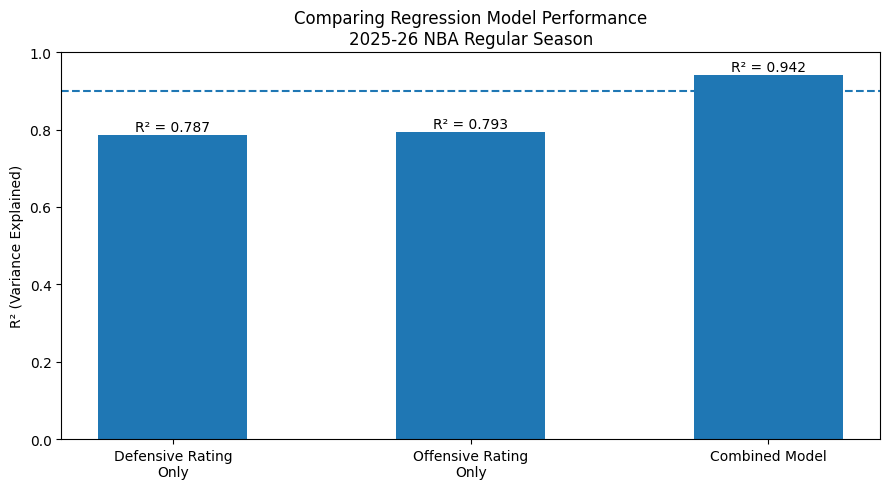

In [12]:
r_squared = [
    model_defense.rsquared,
    model_offense.rsquared,
    model.rsquared
]

models = [
    'Defensive Rating\nOnly',
    'Offensive Rating\nOnly',
    'Combined Model'
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    models,
    r_squared,
    width=0.5
)

plt.ylim(0, 1)

plt.ylabel('R² (Variance Explained)')

plt.title(
    'Comparing Regression Model Performance\n2025-26 NBA Regular Season'
)

plt.axhline(
    y=0.9,
    linestyle='--'
)

for bar, value in zip(bars, r_squared):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f'R² = {value:.3f}',
        ha='center'
    )

plt.tight_layout()

plt.show()

### Model Comparison Insight

The comparison reveals that Offensive Rating and Defensive Rating individually explain a similar proportion of variation in team success, with both models achieving R² values close to 0.79.

However, the combined model substantially outperformed either individual model, explaining approximately 94% of the variation in winning percentage.

This suggests that offensive and defensive efficiency provide complementary information rather than competing explanations of success. While each factor independently contributes to winning, the strongest understanding of team performance emerges when both dimensions are considered together.

These findings further support the use of Net Rating as a summary measure of overall team quality, as it effectively captures the balance between offensive and defensive performance.

## 5. Overall Team Efficiency and Winning Success

Net Rating combines both offensive and defensive efficiency into a single metric, representing a team's overall point differential per 100 possessions.

This visualization examines how strongly connected overall team efficiency is to the winning percentage of an NBA team, allowing for a comparision between their combined impact versus their individual impact when analyzed seperately.

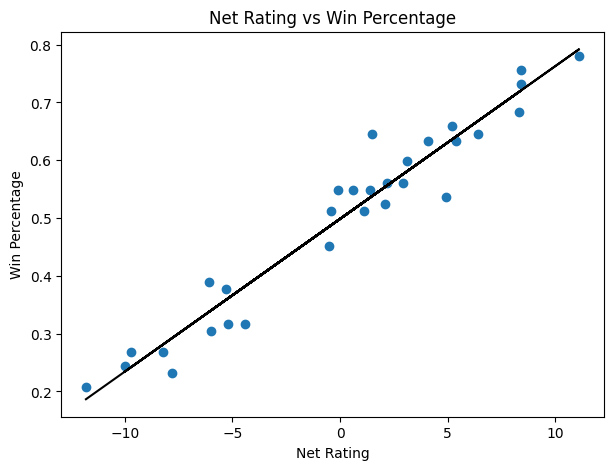

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(selected_df['NET_RATING'], selected_df['W_PCT'])

x = selected_df['NET_RATING']
y = selected_df['W_PCT']

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black')
plt.xlabel('Net Rating')
plt.ylabel('Win Percentage')

plt.title('Net Rating vs Win Percentage')

plt.show()

### Correlation Comparison Table

In [14]:
correlation_matrix = selected_df.drop(columns=['TEAM_NAME']).corr()
comparison = correlation_matrix.loc[
    ['OFF_RATING', 'DEF_RATING', 'NET_RATING'],
    ['W_PCT']
]

comparison

,W_PCT
OFF_RATING,0.890417
DEF_RATING,-0.886921
NET_RATING,0.970743


### Comparative Efficiency Interpretation

The visualization shows an extremely strong positive relationship between Net Rating and Win Percentage.

The correlation matrix supports this relationship, showing that Net Rating had the strongest correlation with winning percentage in the dataset (r = 0.970), exceeding both Offensive Rating (r = 0.890) and Defensive Rating (r = -0.886).

Teams with higher Net Ratings consistently achieved better records during the 2025-26 NBA season, suggesting that overall is one of the most reliable indicators of success.

The strength of this relationship demonstrates that Net Rating can serve as an effective summary measure of team quality, combining both offensive and defensive performance into a single metric that closely reflects real-world outcomes.

While Net Rating provides a strong indication of overall team strength, some deviation around the regression line still exists. This suggests that factors such as injuries, roster depth, late-game execution, matchup dynamics, and schedule difficulty may also influence team performance beyond what efficiency metrics alone can capture, thus proving to be reliable but not always showing the full picture.

## 6. Comparing Efficiency Rankings to Actual NBA Standings

Based on the previous analysis and findings, Net Rating demonstrated the strongest overall relationship with winning percentage among all evaluated variables.

This section applies Net Rating as a simplified indicator of overall efficiency and compares these rankings to the actual NBA standings in order to evaluate how accurately overall two-way efficiency reflects real team success.

To measure this relationship, Spearman's Rank Correlation was used to compare team rankings based on Net Rating against final league standings for 2025-26 NBA regular season.


In [15]:
analysis_df = selected_df[[
    'TEAM_NAME',
    'W_PCT',
    'NET_RATING'
]].copy()

analysis_df['Standings_Rank'] = (
    analysis_df['W_PCT']
    .rank(ascending=False, method='min')
    .astype(int)
)

analysis_df['NetRating_Rank'] = (
    analysis_df['NET_RATING']
    .rank(ascending=False, method='min').astype(int)
)

analysis_df = analysis_df.sort_values(
    by='Standings_Rank'
)

analysis_df

,TEAM_NAME,W_PCT,NET_RATING,Standings_Rank,NetRating_Rank
20,Oklahoma City Thunder,0.780,11.1,1,1
26,San Antonio Spurs,0.756,8.4,2,2
8,Detroit Pistons,0.732,8.4,3,2
1,Boston Celtics,0.683,8.3,4,4
7,Denver Nuggets,0.659,5.2,5,7
19,New York Knicks,0.646,6.4,6,5
13,Los Angeles Lakers,0.646,1.5,6,14
5,Cleveland Cavaliers,0.634,4.1,8,9
10,Houston Rockets,0.634,5.4,8,6
17,Minnesota Timberwolves,0.598,3.1,10,10


In [16]:
corr_matrix = analysis_df[[
    'Standings_Rank',
    'NetRating_Rank'
]].corr(method='spearman')

rho = corr_matrix.loc[
    'Standings_Rank',
    'NetRating_Rank'
]

print("--- Spearman Rank Correlation ---")
print("Spearman Correlation (Rho): "+ str(round(rho,4)))

--- Spearman Rank Correlation ---
Spearman Correlation (Rho): 0.9507


### Rank Correlation Insight 

Although the Spearman rank correlation showed a very strong relationship between Net Rating rankings and overall NBA standings, the analysis also presented several deviations between the statistical efficiency and final season outcomes.

For example, the Los Angeles Lakers finished significantly higher in the standings relative to their Net Rating rank. This outcome aligns with external analysis from NBA.com, which highlighted the Lakers’ exceptional clutch-time offensive efficiency, defensive improvement, and late-game execution throughout the season (Schuhmann, 2026). These factors likely played a role in the team to outperform their overall efficiency in close-game situations.

Similarly, the Charlotte Hornets produced a decent Net Rating rank of 8th overall despite finishing noticeably lower in the standings of 16th in the league. According to NBA.com analysis, Charlotte experienced extreme season splits, dominant blowout victories, and poor clutch-game performance, causing their efficiency metrics to outperform their actual standings position (Schuhmann, 2026). The article also noted that the Hornets posted one of the strongest five-man lineup Net Ratings in the league while struggling to consistently convert close games into wins, thereby revealing how other basketball factors can influence winning outcomes beyond overall efficiency metrics alone.

In contrast, teams such as the Oklahoma City Thunder and Boston Celtics showed strong alignment between standings rank and Net Rating rank, reinforcing the reliability of overall efficiency as a long-term indicator of team strength.

These findings suggest that while Net Rating is highly effective at evaluating overall team quality, other factors such as clutch performance, injuries, lineup consistency, schedule strength, and inconsistency in close-game outcomes may still influence final NBA standings beyond what efficiency metrics alone can explain.


## Key Findings

**Finding 1: Offensive and defensive efficiency contribute similarly to team success**

Offensive Rating (R² = 0.793) and Defensive Rating (R² = 0.787) explained nearly identical proportions of variation in winning percentage. Although offensive efficiency is marginally more significant. This suggests that offense and defense are both critical components of NBA success, with neither demonstrating a substantial advantage as a standalone predictor. 

**Finding 2: Team balance is more predictive than either dimension alone**

When Offensive Rating and Defensive Rating were combined into a single regression model, the explanatory power increased substantially (R² = 0.942). This indicates that successful teams are typically strong on both ends of the floor rather than relying primarily on offense or defense.

**Finding 3: Defensive efficiency have a greater impact than other highlight statistics**

Among the defensive metrics examined, overall Defensive Rating, defensive rebounding and turnovers demonstrated stronger relationships with winning percentage than steals or blocks. This suggests that consistent defensive execution and possession control contribute more to long-term success than individual defensive plays.

**Finding 4: Net Rating closely reflects real-world team performance**

Net Rating showed the strongest overall relationship with winning percentage (r = 0.971) and closely aligned with league standings. This reinforces its value as a practical summary measure of overall team quality.

**Finding 5: Contextual factors can influence outcomes beyond efficiency metrics**

Although efficiency metrics explained most of the variation in team success, teams such as the Los Angeles Lakers and Charlotte Hornets demonstrated meaningful deviations between statistical performance and final standings. Factors such as clutch performance, injuries, roster depth, and close-game execution may influence outcomes beyond what efficiency metrics alone can capture.


## Conclusion

This analysis examined the relationship between offensive efficiency, defensive efficiency, and NBA team success during the 2025–26 regular season.

The results showed that both offense and defense are highly important predictors of winning. Offensive Rating and Defensive Rating individually explained similar proportions of variation in team success, with offensive rating being a slightly stronger determinant, suggesting that neither side of the ball dominates the other as a standalone factor. However, when both metrics were combined, the resulting model explained approximately 94% of the variation in winning percentage, highlighting the importance of overall team balance.

The analysis also demonstrated that Net Rating serves as an effective summary measure of team quality. As a combined representation of offensive and defensive efficiency, Net Rating showed the strongest relationship with winning percentage and closely mirrored actual NBA standings. This suggests that overall efficiency provides a reliable indicator of long-term team success.

The findings broadly support the idea that defensive performance is just as important as offensive performance in determining NBA outcomes. While offensive metrics often receive greater attention in modern basketball discussions, the results indicate that elite defense remains an equally valuable contributor to winning.

At the same time, the standings comparison revealed that statistical efficiency does not capture every aspect of team performance. Teams such as the Los Angeles Lakers and Charlotte Hornets displayed meaningful differences between their efficiency profiles and final standings, suggesting that factors such as clutch performance, injuries, roster construction, lineup consistency, and schedule difficulty may also affect season outcomes.

A limitation of this study is that it focuses exclusively on regular season data. Future research could incorporate playoff performance, player-level metrics, and situational statistics to determine whether these relationships remain consistent under postseason conditions. Another limitation is that this study only considered one NBA season, which may reveal far different results.

Overall, the evidence suggests that the most successful NBA teams are not defined solely by elite offense or elite defense, but by their ability to consistently perform at a high level on both ends of the court.


<div style="padding-left: 36px; text-indent: -36px;">

## References

Schuhmann, J. (2026). *4 reasons why Lakers have evolved into a contender*. NBA.com. https://www.nba.com/news/4-reasons-los-angeles-lakers-are-contender

Schuhmann, J. (2026). *Hornets make some history amid their turnaround season*. NBA.com. https://www.nba.com/news/hornets-improvement-2025-26-season

NBA API. (2026). *LeagueDashTeamStats advanced statistics endpoint*. NBA Stats API.

</div>
